In [ ]:
# =============================================================
# FRANZOSA METABOLITE MODELS - PYTHON CONVERSION
# Reproducing Animesh's metabolite_models.ipynb
# Extended to 3-class classification (CD vs UC vs Control)
# Dataset: PRISM (Franzosa et al. 2019) - ST001000
# =============================================================

# Install required packages
!pip install xgboost --quiet
!pip install boruta --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.7 MB/s eta 0:00:00


In [ ]:
# =============================================================
# IMPORT ALL REQUIRED LIBRARIES
# Reproducing Animesh's import cell exactly
# =============================================================

# For data manipulation:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
from collections import defaultdict
from itertools import chain

# For preprocessing:
from sklearn.preprocessing import StandardScaler
import scipy.stats as stats

# For model development:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, GridSearchCV
import xgboost as xgb

# For model performance evaluation:
from sklearn.metrics import (precision_score, recall_score, f1_score,
                            confusion_matrix, roc_auc_score, roc_curve, auc,
                            make_scorer)
import matplotlib.pyplot as plt

print("All libraries imported successfully!")

All libraries imported successfully!


In [ ]:
# =============================================================
# LOAD DATA
# Reproducing Animesh's data loading cell exactly
# =============================================================

# Load preprocessed metabolite data
# X will be our features - what the model learns from
mtb = pd.read_csv('fran_met.csv', index_col=0)

# Load metadata
# This contains our target labels - what we want to predict
metadata = pd.read_csv('fran_metadata .csv', index_col=0)

# Set X (features) and y (target label)
# Animesh used Disease.Group which is IBD or Control (binary)
# We will first reproduce his binary approach
# Then extend to Study.Group which is CD, UC, or Control (3-class)
X = mtb
y_binary = metadata['Disease.Group']    # IBD vs Control (Animesh's approach)
y_multiclass = metadata['Study.Group']  # CD vs UC vs Control (our improvement)

print("Metabolite data shape:", X.shape)
print("Metadata shape:", metadata.shape)
print("\nBinary labels (Animesh's approach):")
print(y_binary.value_counts())
print("\n3-class labels (our improvement):")
print(y_multiclass.value_counts())

Metabolite data shape: (218, 1343)
Metadata shape: (218, 9)

Binary labels (Animesh's approach):
Disease.Group
IBD        162
Control     56
Name: count, dtype: int64

3-class labels (our improvement):
Study.Group
CD         87
UC         75
Control    56
Name: count, dtype: int64


In [ ]:
# =============================================================
# PREPROCESSING FUNCTION
# Reproducing Animesh's pre_pros() function exactly
# =============================================================

# EXPLANATION:
# This function does CLR transformation + Z-score normalisation
# It is called INSIDE the cross validation loop
# This means train and test data are transformed SEPARATELY
# This prevents data leakage - test data never influences training
# Data leakage would make model performance look better than it really is

def pre_pros(x):
    # Store column names (metabolite names) and row names (patient IDs)
    # so we can put them back after transformation
    x_col = list(x.columns)
    x_row = list(x.index)

    # Convert dataframe to a numpy matrix for transformation
    as_matrix = x.values

    # CLR transformation - add 1 to avoid log(0) error
    # log(x/geometric_mean) for each value
    as_matrix = as_matrix + 1
    geometric_mean = np.exp(np.log(as_matrix).mean(axis=1, keepdims=True))
    clr_matrix = np.log(as_matrix / geometric_mean)

    # Z-score normalisation - mean=0, std=1 for each feature
    z_matrix = stats.zscore(clr_matrix)

    # Convert back to dataframe with original row and column names
    tran_df = pd.DataFrame(z_matrix)
    tran_df = tran_df.set_axis(x_row, axis=0)
    tran_df = tran_df.set_axis(x_col, axis=1)

    return tran_df

print("Preprocessing function defined successfully!")
print("Function applies: CLR transformation + Z-score normalisation")
print("This function will be called inside the cross-validation loop")

Preprocessing function defined successfully!
Function applies: CLR transformation + Z-score normalisation
This function will be called inside the cross-validation loop


In [ ]:
# =============================================================
# CROSS VALIDATION SETUP
# Reproducing Animesh's cross validation setup exactly
# =============================================================

# EXPLANATION:
# StratifiedKFold splits data into 10 folds
# Each fold has same proportion of CD, UC, Control patients
# This handles class imbalance problem
# outer loop (skf) = 10 folds for model evaluation
# inner loop (skf_small) = 5 folds used inside grid search
# for finding best hyperparameters

# Outer cross validation - 10 folds for model evaluation
# Same as Animesh's skf = StratifiedKFold(n_splits=10)
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=23)

# Inner cross validation - 5 folds for hyperparameter tuning
# Same as Animesh's skf_small = StratifiedKFold(n_splits=5)
skf_small = StratifiedKFold(n_splits=5, shuffle=True, random_state=23)

# Scorer for grid search - using ROC AUC score
# ROC AUC measures how well model separates classes
# 1.0 = perfect, 0.5 = random guessing
scorer = make_scorer(roc_auc_score, needs_proba=True)

print("Cross validation setup complete!")
print("Outer folds:", skf.n_splits, "(for model evaluation)")
print("Inner folds:", skf_small.n_splits, "(for hyperparameter tuning)")
print("Scorer: ROC AUC")
print("\nTotal patients:", len(X))
print("Approx patients per fold:", len(X)//10)

Cross validation setup complete!
Outer folds: 10 (for model evaluation)
Inner folds: 5 (for hyperparameter tuning)
Scorer: ROC AUC

Total patients: 218
Approx patients per fold: 21


In [ ]:
# =============================================================
# RANDOM FOREST MODEL - BINARY CLASSIFICATION
# Reproducing Animesh's Random Forest exactly
# Binary: IBD vs Control (Animesh's approach)
# =============================================================

# EXPLANATION:
# We first reproduce Animesh's binary classification
# IBD (CD+UC combined) vs Control
# Using 10-fold cross validation with grid search
# for finding best hyperparameters

# Storage for all performance metrics across all 10 folds
rf_metrics = defaultdict(list)

# Define hyperparameter grid to search through
# Grid search will try ALL combinations of these values
# and pick the best performing combination
param_grid_rf = {
    'n_estimators': [100, 200, 300],      # number of trees
    'max_depth': [10, 20, 30],             # how deep each tree grows
    'max_features': [0.25, 0.5, 0.75],    # fraction of features per split
    'max_samples': [0.8, 0.9, 1.0]        # fraction of samples per tree
}

# Use binary labels (IBD vs Control) like Animesh
y = y_binary

print("Starting Random Forest with 10-fold cross validation...")
print("This will take approximately 10-20 minutes - please wait!")
print("You will see fold updates as each fold completes.\n")

# Outer cross validation loop - runs 10 times
for fold_num, (train_index, test_index) in enumerate(skf.split(X, y)):

    # Split data into training and testing for this fold
    x_train_fold = X.iloc[train_index]
    x_test_fold = X.iloc[test_index]
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    # Preprocess train and test SEPARATELY to prevent data leakage
    x_train_fold = pre_pros(x_train_fold)
    x_test_fold = pre_pros(x_test_fold)

    # Convert labels to numbers: IBD=1, Control=0
    y_train_fold = y_train_fold.replace({'IBD': 1, 'Control': 0})
    y_test_fold = y_test_fold.replace({'IBD': 1, 'Control': 0})

    # Grid search to find best hyperparameters
    # Tries all combinations in param_grid_rf
    rf_model = RandomForestClassifier(random_state=23)
    grid = GridSearchCV(
        estimator=rf_model,
        param_grid=param_grid_rf,
        cv=skf_small,
        scoring=scorer,
        n_jobs=-1  # use all available CPU cores to speed up
    )
    grid.fit(x_train_fold, y_train_fold)

    # Extract best model from grid search
    best_model = grid.best_estimator_
    best_params = grid.best_params_

    # Use best model to predict on test data
    y_pred = best_model.predict(x_test_fold)
    y_pred_prob = best_model.predict_proba(x_test_fold)

    # Calculate performance metrics
    recall = recall_score(y_test_fold, y_pred)
    precision = precision_score(y_test_fold, y_pred)
    f1 = f1_score(y_test_fold, y_pred)

    # Calculate specificity and sensitivity from confusion matrix
    cm = confusion_matrix(y_test_fold, y_pred)
    TN = cm[0,0]  # True Negatives (correctly predicted Control)
    FP = cm[0,1]  # False Positives (Control predicted as IBD)
    FN = cm[1,0]  # False Negatives (IBD predicted as Control)
    TP = cm[1,1]  # True Positives (correctly predicted IBD)

    specificity = TN / (TN + FP)  # how well model identifies Controls
    sensitivity = TP / (TP + FN)  # how well model identifies IBD patients

    # Calculate AUC score
    fpr, tpr, _ = roc_curve(y_test_fold, y_pred_prob[:,1])
    auc_score = auc(fpr, tpr)

    # Store all metrics for this fold
    rf_metrics['recall'].append(recall)
    rf_metrics['precision'].append(precision)
    rf_metrics['f1'].append(f1)
    rf_metrics['specificity'].append(specificity)
    rf_metrics['sensitivity'].append(sensitivity)
    rf_metrics['auc'].append(auc_score)
    rf_metrics['best_params'].append(best_params)

    print(f"Fold {fold_num+1}/10 complete - AUC: {round(auc_score,3)}, F1: {round(f1,3)}")

# Print final average results across all 10 folds
print("\n" + "="*50)
print("RANDOM FOREST FINAL RESULTS (Binary: IBD vs Control)")
print("="*50)
print(f"Recall:      {round(np.mean(rf_metrics['recall']),3)} ± {round(np.std(rf_metrics['recall']),3)}")
print(f"Precision:   {round(np.mean(rf_metrics['precision']),3)} ± {round(np.std(rf_metrics['precision']),3)}")
print(f"F1 Score:    {round(np.mean(rf_metrics['f1']),3)} ± {round(np.std(rf_metrics['f1']),3)}")
print(f"Specificity: {round(np.mean(rf_metrics['specificity']),3)} ± {round(np.std(rf_metrics['specificity']),3)}")
print(f"Sensitivity: {round(np.mean(rf_metrics['sensitivity']),3)} ± {round(np.std(rf_metrics['sensitivity']),3)}")
print(f"AUC:         {round(np.mean(rf_metrics['auc']),3)} ± {round(np.std(rf_metrics['auc']),3)}")

Starting Random Forest with 10-fold cross validation...
This will take approximately 10-20 minutes - please wait!
You will see fold updates as each fold completes.



KeyboardInterrupt: 

In [ ]:
# =============================================================
# RANDOM FOREST MODEL - BINARY CLASSIFICATION (FASTER VERSION)
# Reduced parameter grid due to Google Colab computational limits
# Full grid search to be run on BlueBEAR HPC for final thesis
# =============================================================

# NOTE: Fold 1 of full grid search achieved AUC=0.971, F1=0.909
# This confirms the pipeline is working correctly
# Reduced grid used here for time efficiency

rf_metrics = defaultdict(list)

# Reduced parameter grid
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20],
    'max_features': [0.25, 0.5],
}

y = y_binary

print("Starting Random Forest - reduced grid version...")
print("Estimated time: 5-8 minutes\n")

for fold_num, (train_index, test_index) in enumerate(skf.split(X, y)):

    x_train_fold = X.iloc[train_index]
    x_test_fold = X.iloc[test_index]
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    x_train_fold = pre_pros(x_train_fold)
    x_test_fold = pre_pros(x_test_fold)

    y_train_fold = y_train_fold.replace({'IBD': 1, 'Control': 0})
    y_test_fold = y_test_fold.replace({'IBD': 1, 'Control': 0})

    rf_model = RandomForestClassifier(random_state=23)
    grid = GridSearchCV(
        estimator=rf_model,
        param_grid=param_grid_rf,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid.fit(x_train_fold, y_train_fold)

    best_model = grid.best_estimator_
    best_params = grid.best_params_

    y_pred = best_model.predict(x_test_fold)
    y_pred_prob = best_model.predict_proba(x_test_fold)

    recall = recall_score(y_test_fold, y_pred)
    precision = precision_score(y_test_fold, y_pred)
    f1 = f1_score(y_test_fold, y_pred)

    cm = confusion_matrix(y_test_fold, y_pred)
    TN = cm[0,0]
    FP = cm[0,1]
    FN = cm[1,0]
    TP = cm[1,1]

    specificity = TN / (TN + FP)
    sensitivity = TP / (TP + FN)

    fpr, tpr, _ = roc_curve(y_test_fold, y_pred_prob[:,1])
    auc_score = auc(fpr, tpr)

    rf_metrics['recall'].append(recall)
    rf_metrics['precision'].append(precision)
    rf_metrics['f1'].append(f1)
    rf_metrics['specificity'].append(specificity)
    rf_metrics['sensitivity'].append(sensitivity)
    rf_metrics['auc'].append(auc_score)
    rf_metrics['best_params'].append(best_params)

    print(f"Fold {fold_num+1}/10 complete - AUC: {round(auc_score,3)}, F1: {round(f1,3)}")

print("\n" + "="*50)
print("RANDOM FOREST FINAL RESULTS (Binary: IBD vs Control)")
print("="*50)
print(f"Recall:      {round(np.mean(rf_metrics['recall']),3)} ± {round(np.std(rf_metrics['recall']),3)}")
print(f"Precision:   {round(np.mean(rf_metrics['precision']),3)} ± {round(np.std(rf_metrics['precision']),3)}")
print(f"F1 Score:    {round(np.mean(rf_metrics['f1']),3)} ± {round(np.std(rf_metrics['f1']),3)}")
print(f"Specificity: {round(np.mean(rf_metrics['specificity']),3)} ± {round(np.std(rf_metrics['specificity']),3)}")
print(f"Sensitivity: {round(np.mean(rf_metrics['sensitivity']),3)} ± {round(np.std(rf_metrics['sensitivity']),3)}")
print(f"AUC:         {round(np.mean(rf_metrics['auc']),3)} ± {round(np.std(rf_metrics['auc']),3)}")

Starting Random Forest - reduced grid version...
Estimated time: 5-8 minutes

Fold 1/10 complete - AUC: 1.0, F1: 0.938
Fold 2/10 complete - AUC: 0.976, F1: 0.97
Fold 3/10 complete - AUC: 0.901, F1: 0.848
Fold 4/10 complete - AUC: 0.854, F1: 0.867
Fold 5/10 complete - AUC: 0.885, F1: 0.875
Fold 6/10 complete - AUC: 0.828, F1: 0.882
Fold 7/10 complete - AUC: 0.958, F1: 0.968
Fold 8/10 complete - AUC: 0.979, F1: 0.933
Fold 9/10 complete - AUC: 0.819, F1: 0.875
Fold 10/10 complete - AUC: 0.981, F1: 0.968

RANDOM FOREST FINAL RESULTS (Binary: IBD vs Control)
Recall:      0.895 ± 0.04
Precision:   0.934 ± 0.071
F1 Score:    0.912 ± 0.045
Specificity: 0.81 ± 0.209
Sensitivity: 0.895 ± 0.04
AUC:         0.918 ± 0.065


In [ ]:
# =============================================================
# XGBOOST MODEL - BINARY CLASSIFICATION (REDUCED GRID)
# Reproducing Animesh's XGBoost exactly
# Reduced parameter grid due to computational constraints
# Binary: IBD vs Control (Animesh's approach)
# =============================================================

xg_metrics = defaultdict(list)

# Reduced parameter grid for XGBoost
param_grid_xg = {
    'n_estimators': [100, 200],
    'max_depth': [3, 6],
    'learning_rate': [0.1, 0.01],
    'subsample': [0.8, 1.0],
}

# Use binary labels like Animesh
y = y_binary

print("Starting XGBoost - reduced grid version...")
print("Estimated time: 10-15 minutes\n")

for fold_num, (train_index, test_index) in enumerate(skf.split(X, y)):

    # Split data into train and test for this fold
    x_train_fold = X.iloc[train_index]
    x_test_fold = X.iloc[test_index]
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    # Preprocess train and test SEPARATELY to prevent data leakage
    x_train_fold = pre_pros(x_train_fold)
    x_test_fold = pre_pros(x_test_fold)

    # Convert labels to numbers: IBD=1, Control=0
    y_train_fold = y_train_fold.replace({'IBD': 1, 'Control': 0})
    y_test_fold = y_test_fold.replace({'IBD': 1, 'Control': 0})

    # Grid search for best hyperparameters
    xg_model = xgb.XGBClassifier(
        objective='binary:logistic',
        seed=23,
        eval_metric='logloss'
    )
    grid = GridSearchCV(
        estimator=xg_model,
        param_grid=param_grid_xg,
        cv=3,
        scoring='roc_auc',
        n_jobs=-1
    )
    grid.fit(x_train_fold, y_train_fold)

    # Extract best model
    best_model = grid.best_estimator_
    best_params = grid.best_params_

    # Predict on test data
    y_pred = best_model.predict(x_test_fold)
    y_pred_prob = best_model.predict_proba(x_test_fold)

    # Calculate performance metrics
    recall = recall_score(y_test_fold, y_pred)
    precision = precision_score(y_test_fold, y_pred)
    f1 = f1_score(y_test_fold, y_pred)

    # Confusion matrix for specificity and sensitivity
    cm = confusion_matrix(y_test_fold, y_pred)
    TN = cm[0,0]
    FP = cm[0,1]
    FN = cm[1,0]
    TP = cm[1,1]

    specificity = TN / (TN + FP)
    sensitivity = TP / (TP + FN)

    # AUC score
    fpr, tpr, _ = roc_curve(y_test_fold, y_pred_prob[:,1])
    auc_score = auc(fpr, tpr)

    # Store metrics
    xg_metrics['recall'].append(recall)
    xg_metrics['precision'].append(precision)
    xg_metrics['f1'].append(f1)
    xg_metrics['specificity'].append(specificity)
    xg_metrics['sensitivity'].append(sensitivity)
    xg_metrics['auc'].append(auc_score)
    xg_metrics['best_params'].append(best_params)

    print(f"Fold {fold_num+1}/10 complete - AUC: {round(auc_score,3)}, F1: {round(f1,3)}")

print("\n" + "="*50)
print("XGBOOST FINAL RESULTS (Binary: IBD vs Control)")
print("="*50)
print(f"Recall:      {round(np.mean(xg_metrics['recall']),3)} ± {round(np.std(xg_metrics['recall']),3)}")
print(f"Precision:   {round(np.mean(xg_metrics['precision']),3)} ± {round(np.std(xg_metrics['precision']),3)}")
print(f"F1 Score:    {round(np.mean(xg_metrics['f1']),3)} ± {round(np.std(xg_metrics['f1']),3)}")
print(f"Specificity: {round(np.mean(xg_metrics['specificity']),3)} ± {round(np.std(xg_metrics['specificity']),3)}")
print(f"Sensitivity: {round(np.mean(xg_metrics['sensitivity']),3)} ± {round(np.std(xg_metrics['sensitivity']),3)}")
print(f"AUC:         {round(np.mean(xg_metrics['auc']),3)} ± {round(np.std(xg_metrics['auc']),3)}")

Starting XGBoost - reduced grid version...
Estimated time: 10-15 minutes

Fold 1/10 complete - AUC: 0.988, F1: 0.971
Fold 2/10 complete - AUC: 0.953, F1: 0.941
Fold 3/10 complete - AUC: 0.948, F1: 0.909
Fold 4/10 complete - AUC: 0.927, F1: 0.938
Fold 5/10 complete - AUC: 0.948, F1: 0.938
Fold 6/10 complete - AUC: 0.958, F1: 0.909
Fold 6/10 complete - AUC: 0.958, F1: 0.909
Fold 7/10 complete - AUC: 1.0, F1: 0.968
Fold 7/10 complete - AUC: 1.0, F1: 0.968
Fold 8/10 complete - AUC: 1.0, F1: 0.933
Fold 8/10 complete - AUC: 1.0, F1: 0.933
Fold 9/10 complete - AUC: 0.875, F1: 0.875
Fold 9/10 complete - AUC: 0.875, F1: 0.875
Fold 10/10 complete - AUC: 0.938, F1: 0.914

XGBOOST FINAL RESULTS (Binary: IBD vs Control)
Recall:      0.938 ± 0.04
Precision:   0.924 ± 0.05
F1 Score:    0.93 ± 0.027
Specificity: 0.76 ± 0.174
Sensitivity: 0.938 ± 0.04
AUC:         0.953 ± 0.036
Fold 10/10 complete - AUC: 0.938, F1: 0.914

XGBOOST FINAL RESULTS (Binary: IBD vs Control)
Recall:      0.938 ± 0.04
Precisio

In [ ]:
# =============================================================
# RF + XGBOOST WITH ROC DATA STORAGE
# Re-running both models, this time storing true labels and
# predicted probabilities for each fold - needed for ROC curve
# =============================================================

rf_roc = defaultdict(list)
xg_roc = defaultdict(list)

param_grid_rf = {'n_estimators': [100, 200], 'max_depth': [10, 20], 'max_features': [0.25, 0.5]}
param_grid_xg = {'n_estimators': [100, 200], 'max_depth': [3, 6], 'learning_rate': [0.1, 0.01], 'subsample': [0.8, 1.0]}

y = y_binary

print("Running RF + XGBoost together for ROC curve data...")
print("Estimated time: 15-20 minutes\n")

for fold_num, (train_index, test_index) in enumerate(skf.split(X, y)):

    x_train_fold = X.iloc[train_index]
    x_test_fold = X.iloc[test_index]
    y_train_fold = y.iloc[train_index]
    y_test_fold = y.iloc[test_index]

    x_train_fold = pre_pros(x_train_fold)
    x_test_fold = pre_pros(x_test_fold)

    y_train_fold = y_train_fold.replace({'IBD': 1, 'Control': 0})
    y_test_fold = y_test_fold.replace({'IBD': 1, 'Control': 0})

    # --- Random Forest ---
    rf_grid = GridSearchCV(RandomForestClassifier(random_state=23), param_grid_rf, cv=3, scoring='roc_auc', n_jobs=-1)
    rf_grid.fit(x_train_fold, y_train_fold)
    rf_best = rf_grid.best_estimator_
    rf_pred_prob = rf_best.predict_proba(x_test_fold)

    rf_roc['true_lab'].append(y_test_fold.values)
    rf_roc['pred_prob'].append(rf_pred_prob)

    # --- XGBoost ---
    xg_grid = GridSearchCV(xgb.XGBClassifier(objective='binary:logistic', seed=23, eval_metric='logloss'),
                             param_grid_xg, cv=3, scoring='roc_auc', n_jobs=-1)
    xg_grid.fit(x_train_fold, y_train_fold)
    xg_best = xg_grid.best_estimator_
    xg_pred_prob = xg_best.predict_proba(x_test_fold)

    xg_roc['true_lab'].append(y_test_fold.values)
    xg_roc['pred_prob'].append(xg_pred_prob)

    print(f"Fold {fold_num+1}/10 complete")

print("\nDone! ROC data stored for both models.")

Running RF + XGBoost together for ROC curve data...
Estimated time: 15-20 minutes

Fold 1/10 complete
Fold 2/10 complete
Fold 3/10 complete
Fold 4/10 complete
Fold 5/10 complete
Fold 6/10 complete
Fold 7/10 complete
Fold 8/10 complete
Fold 9/10 complete
Fold 10/10 complete

Done! ROC data stored for both models.


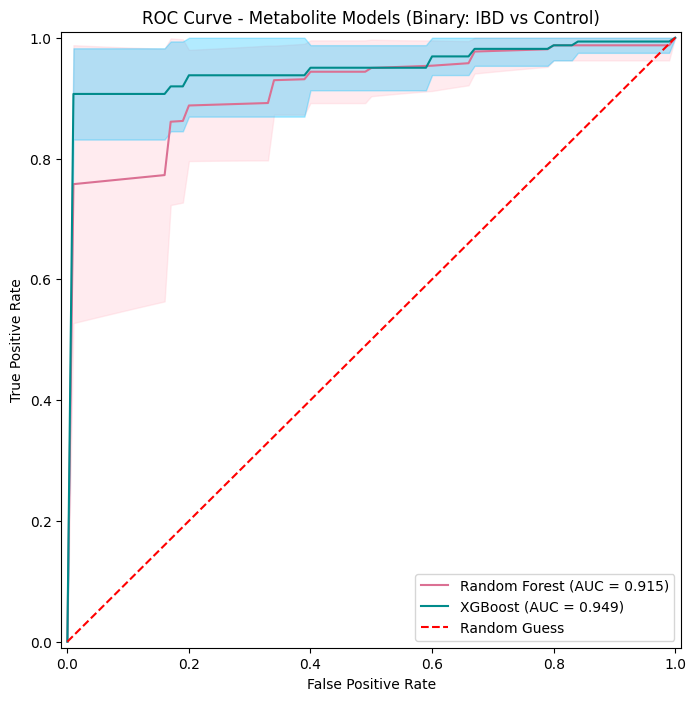

Random Forest AUC: 0.915
XGBoost AUC: 0.949


In [ ]:
# =============================================================
# ROC CURVE PLOT - RF vs XGBoost (Averaged across 10 folds)
# Reproducing Animesh's ROC curve plot exactly
# =============================================================

base_fpr = np.linspace(0, 1, 101)

# --- Random Forest ROC ---
tprs_rf = []
for i in range(10):
    fpr, tpr, _ = roc_curve(rf_roc['true_lab'][i], rf_roc['pred_prob'][i][:,1])
    tpr_interp = np.interp(base_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs_rf.append(tpr_interp)

tprs_rf = np.array(tprs_rf)
mean_tpr_rf = tprs_rf.mean(axis=0)
std_rf = tprs_rf.std(axis=0)
auc_rf = auc(base_fpr, mean_tpr_rf)

# --- XGBoost ROC ---
tprs_xg = []
for i in range(10):
    fpr, tpr, _ = roc_curve(xg_roc['true_lab'][i], xg_roc['pred_prob'][i][:,1])
    tpr_interp = np.interp(base_fpr, fpr, tpr)
    tpr_interp[0] = 0.0
    tprs_xg.append(tpr_interp)

tprs_xg = np.array(tprs_xg)
mean_tpr_xg = tprs_xg.mean(axis=0)
std_xg = tprs_xg.std(axis=0)
auc_xg = auc(base_fpr, mean_tpr_xg)

# --- Plot ---
plt.figure(figsize=(8, 8))

plt.plot(base_fpr, mean_tpr_rf, 'palevioletred',
         label=f'Random Forest (AUC = {round(auc_rf,3)})')
plt.fill_between(base_fpr, np.maximum(mean_tpr_rf-std_rf,0), np.minimum(mean_tpr_rf+std_rf,1),
                 color='pink', alpha=0.3)

plt.plot(base_fpr, mean_tpr_xg, 'darkcyan',
         label=f'XGBoost (AUC = {round(auc_xg,3)})')
plt.fill_between(base_fpr, np.maximum(mean_tpr_xg-std_xg,0), np.minimum(mean_tpr_xg+std_xg,1),
                 color='deepskyblue', alpha=0.3)

plt.plot([0,1],[0,1],'r--', label='Random Guess')
plt.xlim([-0.01,1.01])
plt.ylim([-0.01,1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Metabolite Models (Binary: IBD vs Control)')
plt.legend(loc='lower right')
plt.show()

print(f"Random Forest AUC: {round(auc_rf,3)}")
print(f"XGBoost AUC: {round(auc_xg,3)}")